In [1]:
import numpy as np
import os
import sys
import gzip
import subprocess
import importlib
import pathlib
import shutil
import yaml
import datetime
import pytz
import time
import fnmatch
from scipy.optimize import curve_fit
cwd = os.getcwd()
itop=cwd.find("cgshells/")+len("cgshells")
PROJECT_ROOT = cwd[:itop]
sys.path.insert(0, PROJECT_ROOT )

from utils.readsim import ReadSim
# from utils.curvsim.v1.curvamer2d import Curvamer2D
# from utils.curvsim.v1.curvamer3d import Curvamer3D
import utils.run_manager as rm
# from utils.run_manager import PROJECT_ROOT, lmpunity, lmplocal
version = "v1"    # select which version of curvsim to use
curvsim = importlib.import_module(f"utils.curvsim.{version}")
Curvamer2D = rm.load_class(version, "curvamer2d", "Curvamer2D")
Curvamer3D = rm.load_class(version, "curvamer3d", "Curvamer3D")
versionpath = "/".join(curvsim.__name__.split("."))
DATASCRIPTS = f"{versionpath}/DataScripts"    # location of compatible data scripts (relative to PROJECT_ROOT)

# rm.print_header(version)
# rm.make_simpaths_file(JOBDIR,JOB)     # make empty status file for this job

import matplotlib as mpl
import matplotlib.pyplot as plt

%matplotlib inline

def find_midlayer_pt_3d(mesh_dir,simdir,dumpname,ptx,pty,frame):
    ### load mesh data
    xpos = np.loadtxt("{}/xpos".format(mesh_dir))
    ypos = np.loadtxt("{}/ypos".format(mesh_dir))
    zpos = np.loadtxt("{}/zpos".format(mesh_dir))
    # nlist = np.loadtxt("{}/nlist".format(mesh_dir),dtype=int)
    # indexlist = np.loadtxt("{}/indexlist".format(mesh_dir),dtype=int)
    # npairs = np.loadtxt("{}/npairs".format(mesh_dir),dtype=int)
    # ipairs = np.loadtxt("{}/ipairs".format(mesh_dir),dtype=int)
    atomids = np.loadtxt("{}/atomids".format(mesh_dir),dtype=int)
    # atomtypes = np.loadtxt("{}/atomtypes".format(mesh_dir),dtype=int)
    # bidlist = np.loadtxt("{}/bidlist".format(mesh_dir),dtype=int)
    # btypelist = np.loadtxt("{}/btypelist".format(mesh_dir),dtype=int)

    # wx = np.max(xpos)-np.min(xpos)
    # wy = np.max(ypos)-np.min(ypos)
    natoms = np.size(atomids)
    
    ### read dump file
    result = ReadSim(simdir)
    if (frame==0) or (frame==-1):
        result.read_dump(dumpname=dumpname,readall=False)
    else:
        result.read_dump(dumpname=dumpname,readall=True)
#     result.read_dump(dumpname=dumpname,auto_labels="yes",gz=True)

    ### locate atom nearest to ptx,pty in flat mesh
    dist2 = (xpos-ptx)**2+(ypos-pty)**2
    top = zpos>0
    bot = zpos<0
    iclosest_top = np.argmin(dist2[top])
    iclosest_bot = np.argmin(dist2[bot])
    idtop = atomids[top][iclosest_top]
    idbot = atomids[bot][iclosest_bot]

    ### calculate mid-layer points

    tops = result.dump_id[frame]%natoms == (idtop+1)%natoms
    bots = result.dump_id[frame]%natoms == (idbot+1)%natoms

    dx = result.dump_x[frame][tops]-result.dump_x[frame][bots]
    dy = result.dump_y[frame][tops]-result.dump_y[frame][bots]
    dz = result.dump_z[frame][tops]-result.dump_z[frame][bots]
    rmx = result.dump_x[frame][bots] + 0.5 * dx
    rmy = result.dump_y[frame][bots] + 0.5 * dy
    rmz = result.dump_z[frame][bots] + 0.5 * dz
    dists = np.sqrt(np.diff(rmx)**2 + np.diff(rmy)**2 + np.diff(rmz)**2)

    return (rmx,rmy,rmz,dists)

def latest_traj(files):
    # collect trajectory files
    trajectories = []
    for f in files:
        if f[:10] == "trajectory":
            trajectories.append(f)

    # find latest trajectory file
    tlast = 0
    restart = 0
    for i in np.arange(len(trajectories)):
        traj = trajectories[i]
        p = traj.index(".")
        n = int(traj[10:p])
        if n > restart:
            tlast = i
            restart = n
    dumpname = trajectories[tlast]
    return dumpname

def molradius(result,frame,mol):

    # mol is id of molecule according to lammps (starts from 1 not zero)
        
    nshells = np.max(result.dump_mol)    # number of molecules in simulation
    molatoms = result.natoms/nshells    # number of atoms per molecule
    mask = (result.dump_mol[frame]==mol)    # selects atoms in molecule mol
    idmin = np.min(result.dump_id[frame][mask])
    minmask = (result.dump_id[frame][mask] == idmin)
    idmax = np.max(result.dump_id[frame][mask])
    maxmask = (result.dump_id[frame][mask] == idmax)
    idmid = int((idmax-idmin)/2 + idmin)
    midmask = (result.dump_id[frame][mask] == idmid)
    botmask = (result.dump_id[frame][mask]>=idmin) * (result.dump_id[frame][mask]<=idmid)    # atoms in bottom layer
    topmask = (result.dump_id[frame][mask]>idmid) * (result.dump_id[frame][mask]<=idmax)    # top layer


    # find virtual mid-layer positions
    midx = result.dump_x[frame][mask][botmask] + (result.dump_x[frame][mask][topmask] - result.dump_x[frame][mask][botmask])/2
    midy = result.dump_y[frame][mask][botmask] + (result.dump_y[frame][mask][topmask] - result.dump_y[frame][mask][botmask])/2
    midx_left = midx[0]
    midx_right = midx[-1]
    midy_left = midy[0]
    midy_right = midy[-1]
    idcenter = int(len(midx)/2)
    midx_center = midx[idcenter]
    midy_center = midy[idcenter]

    # fit circle to end points and center-most point in mid-layer
    rfit = ReadSim.fitcircle(midx_left,midy_left,midx_center,midy_center,midx_right,midy_right)
    
    return rfit

Text(0, 0.5, 'Energy Density E/N')

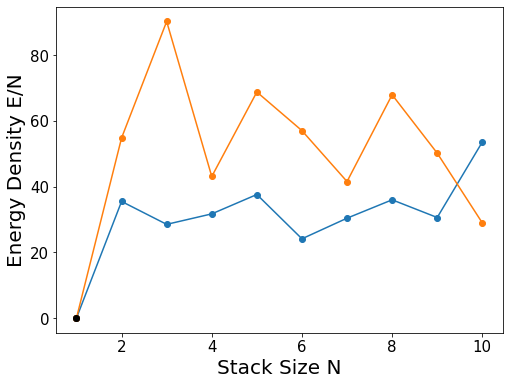

In [19]:
dimension = 2
dcore = 1
wx = 4.9 * dcore
t0 = 0.6 * dcore
r0 = 6.5 * dcore
pair_ints = "1patch"
soft_ints = False
Nbeads = 50 #15

sigma = 0.25 #0.25 * dcore
Eadh = 1
khlist = [100,200]
# khlist = [100,200,250,300,350,400,450,500,550,600,650,700,750,800,850,900,950,1000]
# khlist = [1000]

minstyle = "cg"
etol = 1e-12

nshell_list = np.arange(1,10+1,1)

fig, ax = plt.subplots(1,1,figsize=(8,6))

nminlist = []
khmin = []

for kh in khlist:
    
    nmols = []
    energies = []
    
    for nshells in nshell_list:
#         simpath = f"data/dynamics2D/{int(dimension)}d/emin/wx-{wx:0.3f}-t0-{t0:0.3f}-Nbeads-{Nbeads}/r0-{r0:0.3f}/{pair_ints}-soft-{soft_ints}/Eadh-{Eadh:0.3f}/sigma-{sigma:0.5f}-kh-{kh:0.3f}/nshells-{nshells}/{minstyle}-{int(np.abs(np.log10(etol)))}"

#         simpath = f"data/dynamics2D/{int(dimension)}d/emin/wx-{wx:0.3f}-t0-{t0:0.3f}-Nbeads-{Nbeads}/r0-{r0:0.3f}/{pair_ints}-soft-{soft_ints}/sigma-{sigma:0.5f}-kh-{kh:0.3f}/nshells-{nshells}/{minstyle}-{int(np.abs(np.log10(etol)))}"
        simpath = f"data/examples/{int(dimension)}d/emin/wx-{wx:0.3f}-t0-{t0:0.3f}-Nbeads-{int(Nbeads)}/r0-{r0:0.3f}/sigma-{sigma:0.5f}/kh-{kh:0.5f}/nshells-{nshells}/{minstyle}-{int(np.abs(np.log10(etol)))}"

    #         simpath = f"data/examples/{int(dimension)}d/emin/kh-{kh:0.2f}/nshells-{nshells}"
#         simpath = f"data/{int(dimension)}d/sigma-{sigma:0.3f}-kh-{kh:0.2f}/nshells-{nshells}"
#         simpath = f"data/{int(dimension)}d/wx-{wx:0.2f}-t0-{t0:0.2f}-r0-{r0:0.2f}-Nbeads-{Nbeads}-{pair_ints}/sigma-{sigma:0.3f}-kh-{kh:0.2f}/nshells-{nshells}"
#         simpath = f"data/{int(dimension)}d/stack-emin/wx-{wx:0.3f}-t0-{t0:0.3f}-Nbeads-{Nbeads}-r0-{r0:0.3f}/{pair_ints}/sigma-{sigma:0.5f}-soft-{soft_ints}/kh-{kh:0.3f}/nshells-{nshells}"
        try:
            simdir = f"{PROJECT_ROOT}/{simpath}" 
            # logname = "logmd.lammps"
    #             logname = "logemin.lammps"
            result = ReadSim(simdir)
            result.read_log()
            ef = result.energyf    # final energy
            ef = result.thermo[-1,5]
            energies.append(ef)
            nmols.append(nshells)
            
        except:
            pass
        
    nmols = np.array(nmols)
    energies = np.array(energies)
    ax.plot(nmols,energies/nmols,"o-",label=f"kh = {kh}")
    imin = np.argmin(energies/nmols)
    nmin = nmols[imin]
    emin = energies[imin]/nmin
    ax.plot(nmin,emin,"ko")
    nminlist.append(nmin)
    khmin.append(kh)

# ax.set_xlim(0,15)
# ax.set_ylim(-0.7,-0.5)
# ax.legend(fontsize = 12)
ax.tick_params(labelsize=15)
ax.set_xlabel("Stack Size N",fontsize=20)
ax.set_ylabel("Energy Density E/N",fontsize=20)

In [10]:
result.thermo_labels[5]

'E_bond'

In [12]:
result.thermo[-1,5]

0.65019703

## Larger Design

Text(0, 0.5, 'Energy Density E/N')

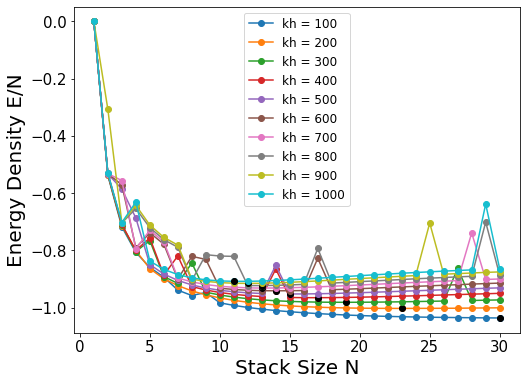

In [21]:
dimension = 2
dcore = 1
wx = 10 #4.9 * dcore
t0 = 0.6 * dcore
r0 = 16 * dcore
pair_ints = "1patch"
soft_ints = True
Nbeads = 30 #15

sigma = 0.25 #0.25 * dcore
# epsilon = 0.004402158148617929
# khlist = [400,600,800,1000,1200]
khlist = [100,200,300,400,500,600,700,800,900,1000]
# khlist = [100]

minstyle = "hftn"
etol = 1e-14

nshell_list = np.arange(1,50+1,1)

fig, ax = plt.subplots(1,1,figsize=(8,6))

nminlist = []
khmin = []

for kh in khlist:
    
    nmols = []
    energies = []
    
    for nshells in nshell_list:
        simpath = f"data/dynamics2D/{int(dimension)}d/emin/wx-{wx:0.3f}-t0-{t0:0.3f}-Nbeads-{Nbeads}/r0-{r0:0.3f}/{pair_ints}-soft-{soft_ints}/sigma-{sigma:0.5f}-kh-{kh:0.3f}/nshells-{nshells}/{minstyle}-{int(np.abs(np.log10(etol)))}"
#         simpath = f"data/examples/{int(dimension)}d/emin/kh-{kh:0.2f}/nshells-{nshells}"
#         simpath = f"data/{int(dimension)}d/sigma-{sigma:0.3f}-kh-{kh:0.2f}/nshells-{nshells}"
#         simpath = f"data/{int(dimension)}d/wx-{wx:0.2f}-t0-{t0:0.2f}-r0-{r0:0.2f}-Nbeads-{Nbeads}-{pair_ints}/sigma-{sigma:0.3f}-kh-{kh:0.2f}/nshells-{nshells}"
#         simpath = f"data/{int(dimension)}d/stack-emin/wx-{wx:0.3f}-t0-{t0:0.3f}-Nbeads-{Nbeads}-r0-{r0:0.3f}/{pair_ints}/sigma-{sigma:0.5f}-soft-{soft_ints}/kh-{kh:0.3f}/nshells-{nshells}"
        try:
            simdir = f"{PROJECT_ROOT}/{simpath}" 
            # logname = "logmd.lammps"
    #             logname = "logemin.lammps"
            result = ReadSim(simdir)
            result.read_log()
            ef = result.energyf    # final energy
            energies.append(ef)
            nmols.append(nshells)
            
        except:
            pass
        
    nmols = np.array(nmols)
    energies = np.array(energies)
    ax.plot(nmols,energies/nmols,"o-",label=f"kh = {kh}")
    imin = np.argmin(energies/nmols)
    nmin = nmols[imin]
    emin = energies[imin]/nmin
    ax.plot(nmin,emin,"ko")
    nminlist.append(nmin)
    khmin.append(kh)

# ax.set_xlim(0,15)
# ax.set_ylim(-0.7,-0.5)
ax.legend(fontsize = 12)
ax.tick_params(labelsize=15)
ax.set_xlabel("Stack Size N",fontsize=20)
ax.set_ylabel("Energy Density E/N",fontsize=20)

In [30]:
r1 = 6.5
r2 = 10
(r2**(4/3)) / (r1**(4/3))

1.7760241127143375

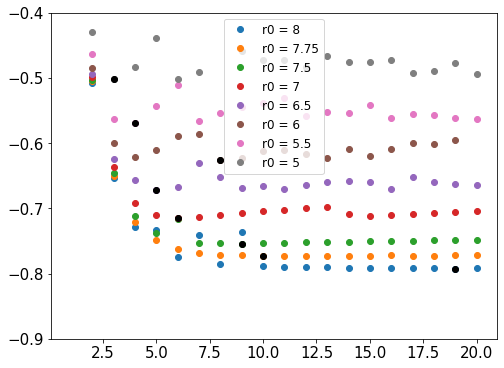

In [97]:
dimension = 2
dcore = 1
wx = 4.9 #4.9 * dcore
t0 = 0.6 * dcore
# r0 = 7.75 #20 * dcore
pair_ints = "1patch"
soft_ints = False 
Nbeads = 15 #15

sigma = 0.25 #0.25 * dcore
# epsilon = 0.004402158148617929
kh = 1000
r0list = [8,7.75,7.5,7,6.5,6,5.5,5]
# r0list = [16,18,20,22,24,26,28,30]


minstyle = "hftn"
etol = 1e-14

nshell_list = np.arange(1,20+1,1)

fig, ax = plt.subplots(1,1,figsize=(8,6))

nminlist = []
khmin = []

for r0 in r0list:
    
    nmols = []
    energies = []
    
    for nshells in nshell_list:
        simpath = f"data/dynamics2D/{int(dimension)}d/emin/wx-{wx:0.3f}-t0-{t0:0.3f}-Nbeads-{Nbeads}/r0-{r0:0.3f}/{pair_ints}-soft-{soft_ints}/sigma-{sigma:0.5f}-kh-{kh:0.3f}/nshells-{nshells}/{minstyle}-{int(np.abs(np.log10(etol)))}"
#         simpath = f"data/examples/{int(dimension)}d/emin/kh-{kh:0.2f}/nshells-{nshells}"
#         simpath = f"data/{int(dimension)}d/sigma-{sigma:0.3f}-kh-{kh:0.2f}/nshells-{nshells}"
#         simpath = f"data/{int(dimension)}d/wx-{wx:0.2f}-t0-{t0:0.2f}-r0-{r0:0.2f}-Nbeads-{Nbeads}-{pair_ints}/sigma-{sigma:0.3f}-kh-{kh:0.2f}/nshells-{nshells}"
#         simpath = f"data/{int(dimension)}d/stack-emin/wx-{wx:0.3f}-t0-{t0:0.3f}-Nbeads-{Nbeads}-r0-{r0:0.3f}/{pair_ints}/sigma-{sigma:0.5f}-soft-{soft_ints}/kh-{kh:0.3f}/nshells-{nshells}"
        try:
            simdir = f"{PROJECT_ROOT}/{simpath}" 
            # logname = "logmd.lammps"
    #             logname = "logemin.lammps"
            result = ReadSim(simdir)
            result.read_log()
            ef = result.energyf    # final energy
            energies.append(ef)
            nmols.append(nshells)
            
        except:
            pass
        
    nmols = np.array(nmols)
    energies = np.array(energies)
    ax.plot(nmols,energies/nmols,"o",label=f"r0 = {r0}")
    imin = np.argmin(energies/nmols)
    nmin = nmols[imin]
    emin = energies[imin]/nmin
    ax.plot(nmin,emin,"ko")
    
    nminlist.append(nmin)
    khmin.append(kh)

# ax.set_xlim(0,41)
ax.set_ylim(-0.9,-0.4)
ax.legend(fontsize = 12)
ax.tick_params(labelsize=15)

In [ ]:
[8,7.75,7.5,7,6.5,6,5.5,5]

In [ ]:
[19,10,9,6,5,4,4,3]

# DNA Origami

Text(0, 0.5, 'Energy Density E/N')

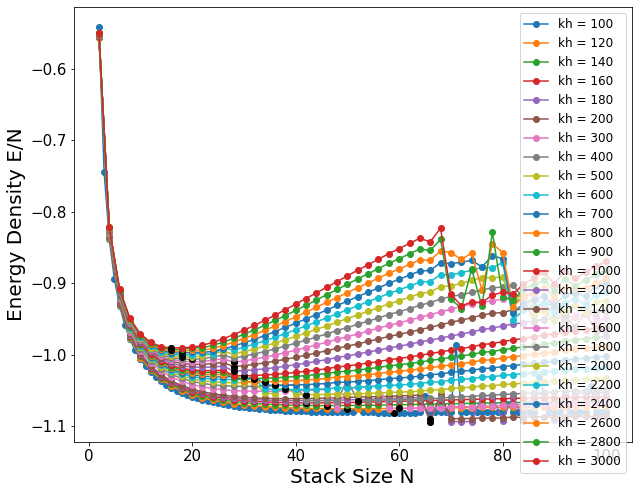

In [22]:
dimension = 2
dcore = 1
wx = 46 * dcore
t0 = 0.6 * dcore
# r0 = 25 * dcore
r0 = 50 * dcore
pair_ints = "1patch"
soft_ints = False
Nbeads = 130

sigma = 0.25 * dcore
khlist = [100,120,140,160,180,200,300,400,500,600,700,800,900,1000,
          1200,1400,1600,1800,2000,2200,2400,2600,2800,3000]
# khlist = [3000]


minstyle = "cg"
# etol = 1e-14
etol = 1e-10


# nshell_list = np.arange(1,50+1,1)
nshell_list = np.arange(1,100+1,1)

fig, ax = plt.subplots(1,1,figsize=(10,8))

nminlist = []
khmin = []

for kh in khlist:
    
    nmols = []
    energies = []
    ebonds = []
    epairs = []
    
    worked = 0
    
    for nshells in nshell_list:
        simpath = f"data/DNA/{int(dimension)}d/emin/wx-{wx:0.3f}-t0-{t0:0.3f}-Nbeads-{int(Nbeads)}/r0-{r0:0.3f}/sigma-{sigma:0.5f}/kh-{kh:0.5f}/nshells-{nshells}/{minstyle}-{int(np.abs(np.log10(etol)))}"
        try:
            simdir = f"{PROJECT_ROOT}/{simpath}" 
            # logname = "logmd.lammps"
    #             logname = "logemin.lammps"
            result = ReadSim(simdir)
            result.read_log()
            ef = result.energyf    # final energy
            energies.append(ef)
            nmols.append(nshells)
            ebonds.append(result.thermo_E_bond[-1])
            epairs.append(result.thermo_E_pair[-1])
            worked = 1
            
        except:
            pass
        
    if worked == 1:
        nmols = np.array(nmols)
        energies = np.array(energies)
        ebonds = np.array(ebonds)
        epairs = np.array(epairs)
        ax.plot(nmols,energies/nmols,"o-",label=f"kh = {kh}")
        imin = np.argmin(energies/nmols)
        nmin = nmols[imin]
        emin = energies[imin]/nmin
        ax.plot(nmin,emin,"ko")
        nminlist.append(nmin)
        khmin.append(kh)

# ax.set_xlim(0,80)
# ax.set_ylim(-1.1,-0.8)
ax.legend(fontsize = 12)
ax.tick_params(labelsize=15)
ax.set_xlabel("Stack Size N",fontsize=20)
ax.set_ylabel("Energy Density E/N",fontsize=20)

In [23]:
0.34*8

2.72

Text(0, 0.5, 'Excess Energy Density E/N')

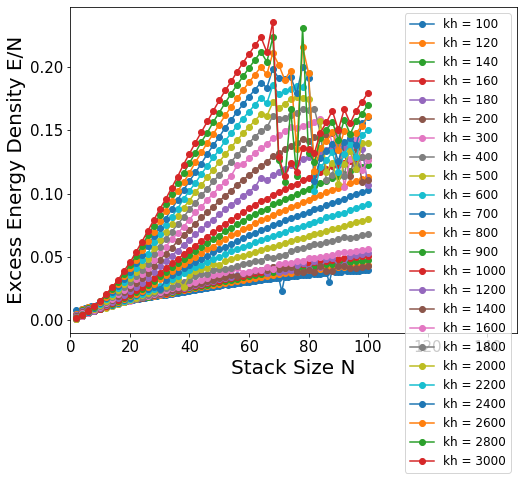

In [24]:
fig, ax = plt.subplots(1,1,figsize=(8,6))

for kh in khlist:
    nmols = []
    energies = []
    ebonds = []
    epairs = []
    
    worked = 0
    
    for nshells in nshell_list:
        simpath = f"data/DNA/{int(dimension)}d/emin/wx-{wx:0.3f}-t0-{t0:0.3f}-Nbeads-{int(Nbeads)}/r0-{r0:0.3f}/sigma-{sigma:0.5f}/kh-{kh:0.5f}/nshells-{nshells}/{minstyle}-{int(np.abs(np.log10(etol)))}"
        try:
            simdir = f"{PROJECT_ROOT}/{simpath}" 
            # logname = "logmd.lammps"
    #             logname = "logemin.lammps"
            result = ReadSim(simdir)
            result.read_log()
            ef = result.energyf    # final energy
            energies.append(ef)
            nmols.append(nshells)
            ebonds.append(result.thermo_E_bond[-1])
            epairs.append(result.thermo_E_pair[-1])
            worked = 1
        except:
            pass
    
    if worked == 1:
        nmols = np.array(nmols)
        energies = np.array(energies)
        ebonds = np.array(ebonds)
        epairs = np.array(epairs)
        ax.plot(nmols,ebonds/nmols,"o-",label=f"kh = {kh}")

ax.set_xlim(0,150)
# ax.set_ylim(-0.7,-0.5)
ax.legend(fontsize = 12)
ax.tick_params(labelsize=15)
ax.set_xlabel("Stack Size N",fontsize=20)
ax.set_ylabel("Excess Energy Density E/N",fontsize=20)

In [25]:
nminlist

[59,
 50,
 46,
 42,
 66,
 66,
 60,
 52,
 42,
 38,
 36,
 34,
 32,
 30,
 28,
 28,
 28,
 20,
 18,
 18,
 18,
 18,
 16,
 16]

In [7]:
def sconformal(h):
    return (2-2*np.sqrt(h**2+1))/h + np.arcsinh(h)

Text(0, 0.5, 'N*')

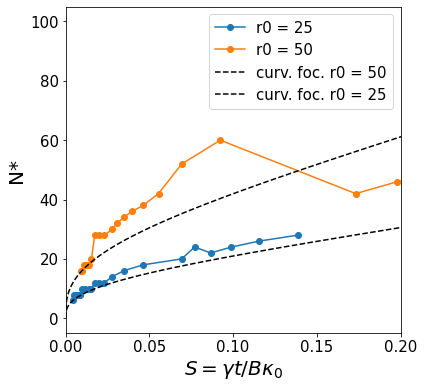

In [26]:
### r0 = 50
r0 = 50
kh_list = np.array([100, 120, 140, 160, 180, 200, 300, 400, 500, 600, 700, 800, 900, 1000, 1200, 1400, 1600, 1800, 2000, 2200, 2400, 2600, 2800, 3000])
eflat_list = np.array([0.0577220008298142, 0.069266400995777, 0.0808108011617399, 0.0923552013277028, 0.103899601493666, 0.115444001659628, 0.173166002489443, 0.230888003319257, 0.288610004149071, 0.346332004978885, 0.404054005808699, 0.461776006638513, 0.519498007468328, 0.577220008298143, 0.692664009957771, 0.808108011617399, 0.923552013277026, 1.03899601493666, 1.15444001659628, 1.26988401825591, 1.38532801991554, 1.50077202157517, 1.6162160232348, 1.73166002489443])
eadh = 1


nmax = 60
mask = np.array(nminlist)<=nmax

slist = ((t0+dcore) * eadh) / ( 2*eflat_list*r0 )

fig, ax = plt.subplots(1,1,figsize=(6,6))
ax.plot(x25,y25,"o-",label = f"r0 = 25")
ax.plot(slist[mask],np.array(nminlist)[mask],"o-",label = f"r0 = {r0}")

# ax.plot(slist[mask],np.array(nminlist)[mask],"o-",label = f"sigma = {sigma}")
nconf = np.linspace(0.1,100,100)
hconf = 1*((t0+dcore)/r0)*nconf
ax.plot(1*sconformal(hconf),nconf,"k--",label = f"curv. foc. r0 = 50")
ax.plot(1*sconformal(hconf25),nconf,"k--",label = f"curv. foc. r0 = 25")


ax.set_xlim(0,0.2)
# ax.set_ylim(0,50)
ax.legend(fontsize = 15)
ax.tick_params(labelsize=15)
ax.set_xlabel("$S = \gamma t / B \kappa_0$",fontsize=20)
ax.set_ylabel("N*",fontsize=20)

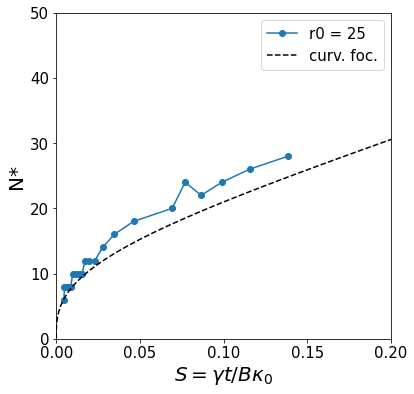

In [21]:
### r0 = 25
r0 = 25
kh_list = np.array([100, 120, 140, 160, 180, 200, 300, 400, 500, 600, 700, 800, 900, 1000, 1200, 1400, 1600, 1800, 2000, 2200, 2400, 2600, 2800, 3000])
eflat_list = np.array([0.230893919072078, 0.277072702886494, 0.32325148670091, 0.369430270515325, 0.41560905432974, 0.461787838144157, 0.692681757216235, 0.923575676288313, 1.15446959536039, 1.38536351443247, 1.61625743350454, 1.84715135257663, 2.0780452716487, 2.30893919072078, 2.77072702886494, 3.23251486700909, 3.69430270515325, 4.15609054329741, 4.61787838144157, 5.07966621958572, 5.54145405772988, 6.00324189587404, 6.46502973401818, 6.92681757216235])

nmax = 40
mask = np.array(nminlist)<=nmax

slist = ((t0+dcore) * eadh) / ( 2*eflat_list*r0 )

fig, ax = plt.subplots(1,1,figsize=(6,6))
# ax.plot(x25,y25,"o-",label = f"r0 = 25")
ax.plot(slist[mask],np.array(nminlist)[mask],"o-",label = f"r0 = {r0}")

# ax.plot(slist[mask],np.array(nminlist)[mask],"o-",label = f"sigma = {sigma}")

nconf = np.linspace(0.1,100,100)
hconf25 = 1*((t0+dcore)/r0)*nconf
ax.plot(1*sconformal(hconf25),nconf,"k--",label = f"curv. foc.")

ax.set_xlim(0,0.2)
ax.set_ylim(0,50)
ax.legend(fontsize = 15)
ax.tick_params(labelsize=15)
ax.set_xlabel("$S = \gamma t / B \kappa_0$",fontsize=20)
ax.set_ylabel("N*",fontsize=20)

x25 = slist[mask]
y25 = np.array(nminlist)[mask]

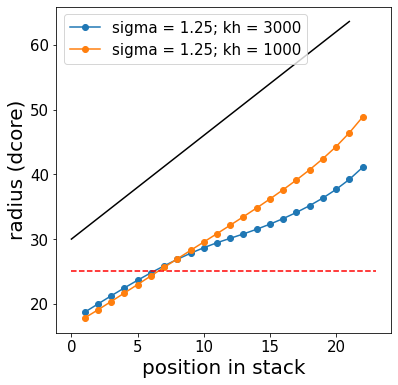

In [263]:
### read dump file
dimension = 2
wx = 46
t0 = 0.6
Nbeads = 130
r0 = 25
sigma = 1.25
khlist = [3000,1000]
minstyle = "cg"
etol = 1e-10
nshells = 22

fig, ax = plt.subplots(1,1,figsize=(6,6))

for kh in khlist:
    simpath = f"data/DNA/{int(dimension)}d/emin/wx-{wx:0.3f}-t0-{t0:0.3f}-Nbeads-{int(Nbeads)}/r0-{r0:0.3f}/sigma-{sigma:0.5f}/kh-{kh:0.5f}/nshells-{nshells}/{minstyle}-{int(np.abs(np.log10(etol)))}"
    simdir = f"{PROJECT_ROOT}/{simpath}"
    readall = True

    result = ReadSim(simdir)
    dumpname = result.latest_file(file="trajectory")
    result.read_dump(dumpname=dumpname,readall=readall)

    frame = -1
    molid = []
    radii = []
    for i in np.arange(1,nshells+1,1):
        mol = i
        rfit = molradius(result,frame,mol)
        molid.append(mol)
        radii.append(rfit)


    ax.plot(np.arange(nshells)+1,np.array(radii),"o-",label = f"sigma = {sigma}; kh = {kh}")

# ax.set_xlim(0,0.2)
# ax.set_ylim(0,50)
ax.legend(fontsize = 15)
ax.tick_params(labelsize=15)
ax.set_xlabel("position in stack",fontsize=20)
ax.set_ylabel("radius (dcore)",fontsize=20)
ax.hlines(r0,xmin=0,xmax=nshells+1,linestyle="dashed",color="red")
ax.plot(np.arange(nshells),((t0+dcore)) * np.arange(nshells)+30,"k-")

In [226]:
frame = -1
molid = []
radii = []
for i in np.arange(1,nshells+1,1):
    mol = i
    rfit = molradius(result,frame,mol)
    molid.append(mol)
    radii.append(rfit)

In [227]:
radii

[39.94863426838186,
 41.61660182966327,
 43.220998144773255,
 44.750914119820656,
 46.20856641056594,
 47.58328085821178,
 48.88166118670278,
 50.13727692765814,
 51.35990632669363,
 52.5635697379027,
 53.76247431932353,
 54.975284123714744,
 56.22211321664611,
 57.526314697909285,
 58.92017249730113,
 60.438543983952286,
 62.13052200742711,
 64.05977327317497,
 66.30894325037238,
 68.93773725299546]

In [22]:
ebonds

array([], dtype=float64)

In [113]:
nshells = 101
px = 1    # number of cpus along x
py = 1
#pz = 1
pmax = 5    # max number of cpus per job
nchunk = 20
if nshells<=nchunk*(pmax-1):
    pz = int(np.floor((nshells-1)/(nchunk))+1)
else:
    pz = int(pmax)
pz

5

In [145]:
len(khlist)*7

168